In [ ]:
'''
!python -m pip install --upgrade setuptools
!python -m pip install swig
!python -m pip install numpy matplotlib torch "gymnasium[box2d,classic-control]" "stable-baselines3>=2.0.0"
'''

In [5]:
import collections
import random
import time

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import gymnasium as gym

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [6]:
env = gym.make("CartPole-v1")
obs, _ = env.reset(seed=42)
print("observation space:", env.observation_space)
print("action space:", env.action_space)

observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
action space: Discrete(2)


### Task 1 — DQN from Scratch on CartPole-v1

Build a DQN agent following the recipe from the lesson — Q-network, replay buffer, target network, ε-greedy exploration.

1. Implement a small Q-network in PyTorch: input dimension = `env.observation_space.shape[0]`, two hidden layers of 128 units with ReLU, output dimension = `env.action_space.n`.
2. Implement a `ReplayBuffer` class that supports `push(state, action, reward, next_state, done)` and `sample(batch_size)`. A `collections.deque(maxlen=50_000)` is plenty for CartPole.
3. Implement the training loop:
   - Keep two networks: `q_net` (trained) and `target_net` (frozen, periodically synced from `q_net`).
   - Use ε-greedy action selection with linear ε decay from `1.0` to `0.05` over the first ~5 000 steps.
   - After at least 1 000 transitions are in the buffer, do one gradient step per environment step on a random mini-batch of 64.
   - Sync `target_net ← q_net` every 1 000 steps.
   - Use `Adam(lr=1e-3)` and γ = 0.99.
4. Run training for **30 000 environment steps** and store the **total reward per episode** in a list.

**Expected behaviour.** A correctly implemented DQN solves `CartPole-v1` (average reward ≥ 475 over 100 episodes) somewhere between 10 000 and 25 000 steps. If your reward is still flat at the end, double-check the target-network sync, the ε decay, and the loss (it should be MSE between `q_net(s).gather(action)` and `r + γ · target_net(s').max()` for non-terminal transitions; just `r` for terminal ones).

5. Plot the per-episode reward and a 100-episode moving average on the same axes. Report the average reward over the last 100 episodes.

In [7]:
import collections
import random
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import gymnasium as gym

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class QNetwork(nn.Module):
    def __init__(self, obs_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )
        
    def forward(self, x):
        return self.net(x)

In [8]:
class ReplayBuffer:
    def __init__(self, maxlen=50_000):
        self.buffer = collections.deque(maxlen=maxlen)
        
    def push(self, state, action, reward, next_state, terminated):
        self.buffer.append((state, action, reward, next_state, terminated))
        
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, terminateds = zip(*batch)
        
        return (
            torch.tensor(np.array(states), dtype=torch.float32).to(device),
            torch.tensor(actions, dtype=torch.int64).to(device),
            torch.tensor(rewards, dtype=torch.float32).to(device),
            torch.tensor(np.array(next_states), dtype=torch.float32).to(device),
            torch.tensor(terminateds, dtype=torch.float32).to(device)
        )
        
    def __len__(self):
        return len(self.buffer)

In [10]:
env = gym.make("CartPole-v1")
obs_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

q_net = QNetwork(obs_dim, action_dim).to(device)
target_net = QNetwork(obs_dim, action_dim).to(device)
target_net.load_state_dict(q_net.state_dict())

optimizer = optim.Adam(q_net.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()
buffer = ReplayBuffer(maxlen=50_000)

total_steps = 30_000
batch_size = 64
gamma = 0.99
sync_freq = 1000
learning_starts = 1000

episode_rewards = []
current_episode_reward = 0
state, _ = env.reset(seed=42)

print(f"Starting DQN training on {device}...")
start_time = time.perf_counter()

for step in range(1, total_steps + 1):
    epsilon = max(0.05, 1.0 - (1.0 - 0.05) * (step / 5000))
    
    if random.random() < epsilon:
        action = env.action_space.sample()
    else:
        with torch.no_grad():
            state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
            q_values = q_net(state_tensor)
            action = q_values.argmax(dim=1).item()
            
    next_state, reward, terminated, truncated, _ = env.step(action)
    current_episode_reward += reward
    
    buffer.push(state, action, reward, next_state, terminated)
    state = next_state
    
    if terminated or truncated:
        episode_rewards.append(current_episode_reward)
        current_episode_reward = 0
        state, _ = env.reset()
        
    if len(buffer) >= learning_starts:
        states, actions, rewards, next_states, terminateds = buffer.sample(batch_size)
        
        q_values = q_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)
        
        with torch.no_grad():
            max_next_q = target_net(next_states).max(dim=1)[0]
            target_q_values = rewards + gamma * max_next_q * (1 - terminateds)
            
        loss = loss_fn(q_values, target_q_values)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    if step % sync_freq == 0:
        target_net.load_state_dict(q_net.state_dict())
        
    if step % 5000 == 0:
        avg_last_100 = np.mean(episode_rewards[-100:]) if episode_rewards else 0
        print(f"Step: {step:5d}/{total_steps} | Epsilon: {epsilon:.2f} | "
              f"Episodes: {len(episode_rewards)} | Avg Reward (last 100): {avg_last_100:.1f}")

dqn_train_time = time.perf_counter() - start_time
print(f"Training complete in {dqn_train_time:.1f} seconds.")

Starting DQN training on cpu...
Step:  5000/30000 | Epsilon: 0.05 | Episodes: 252 | Avg Reward (last 100): 23.4
Step: 10000/30000 | Epsilon: 0.05 | Episodes: 275 | Avg Reward (last 100): 69.3
Step: 15000/30000 | Epsilon: 0.05 | Episodes: 291 | Avg Reward (last 100): 116.2
Step: 20000/30000 | Epsilon: 0.05 | Episodes: 323 | Avg Reward (last 100): 160.5
Step: 25000/30000 | Epsilon: 0.05 | Episodes: 356 | Avg Reward (last 100): 192.8
Step: 30000/30000 | Epsilon: 0.05 | Episodes: 387 | Avg Reward (last 100): 161.0
Training complete in 83.8 seconds.


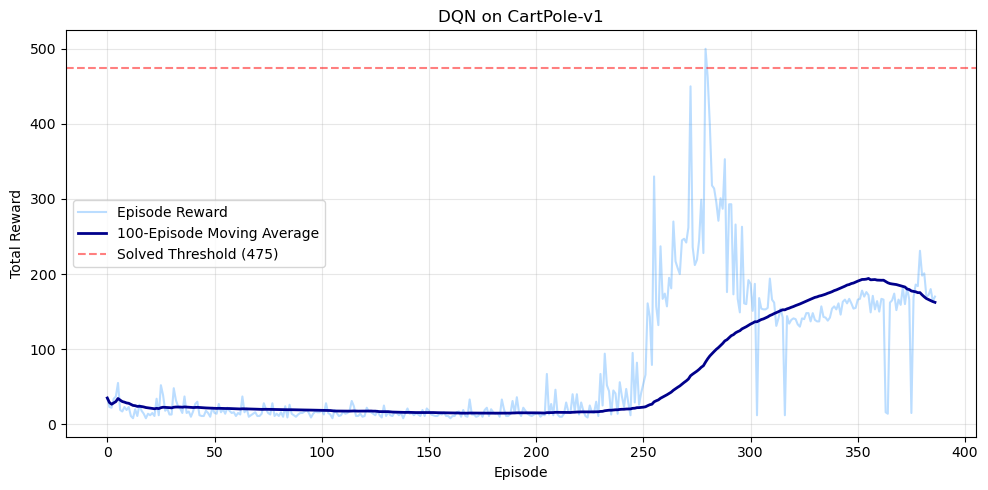

Final 100-episode average reward: 161.0


In [11]:
def plot_rewards(rewards, title="DQN on CartPole-v1"):
    window = 100
    moving_avg = [np.mean(rewards[max(0, i - window):i + 1]) for i in range(len(rewards))]
    
    plt.figure(figsize=(10, 5))
    plt.plot(rewards, alpha=0.3, color='dodgerblue', label='Episode Reward')
    plt.plot(moving_avg, color='darkblue', linewidth=2, label=f'{window}-Episode Moving Average')
    plt.axhline(y=475, color='r', linestyle='--', alpha=0.5, label='Solved Threshold (475)')
    
    plt.title(title)
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_rewards(episode_rewards)

final_avg_reward = np.mean(episode_rewards[-100:])
print(f"Final 100-episode average reward: {final_avg_reward:.1f}")

### Task 2 — PPO with Stable-Baselines3

Now do the same task — and one harder one — with a well-tuned library implementation.

1. Train a **PPO** agent on `CartPole-v1`:

```python
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy

env = gym.make("CartPole-v1")
ppo_cartpole = PPO("MlpPolicy", env, verbose=0, seed=42)
t0 = time.perf_counter()
ppo_cartpole.learn(total_timesteps=50_000)
cartpole_train_time = time.perf_counter() - t0

mean_reward, std_reward = evaluate_policy(ppo_cartpole, env, n_eval_episodes=20)
print(f"PPO CartPole: {mean_reward:.1f} ± {std_reward:.1f} over 20 episodes "
      f"(trained in {cartpole_train_time:.0f}s)")
```

2. Train a second PPO agent on `LunarLander-v2` with the same hyperparameters but **300 000 total timesteps** (this environment is much harder than CartPole).

```python
env_ll = gym.make("LunarLander-v2")
ppo_ll = PPO("MlpPolicy", env_ll, verbose=0, seed=42)
t0 = time.perf_counter()
ppo_ll.learn(total_timesteps=300_000)
ll_train_time = time.perf_counter() - t0

mean_reward, std_reward = evaluate_policy(ppo_ll, env_ll, n_eval_episodes=20)
print(f"PPO LunarLander: {mean_reward:.1f} ± {std_reward:.1f} over 20 episodes "
      f"(trained in {ll_train_time:.0f}s)")
```

3. Use Stable-Baselines3's built-in `Monitor` wrapper or its logger to capture the per-episode rewards during training for both runs, and plot 100-episode moving-average reward curves for both environments.

**Expected behaviour.** PPO solves `CartPole-v1` (reward ≥ 195 on average) within ~20 000 timesteps and reliably reaches the 500 cap. On `LunarLander-v2` PPO usually clears the 200-reward "solved" threshold somewhere between 150 000 and 300 000 timesteps.

In [16]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.results_plotter import load_results, ts2xy

cp_log_dir = "./sb3_logs/cartpole_dir/"
ll_log_dir = "./sb3_logs/lunarlander_dir/"
os.makedirs(cp_log_dir, exist_ok=True)
os.makedirs(ll_log_dir, exist_ok=True)

env_cartpole = gym.make("CartPole-v1")
env_cartpole = Monitor(env_cartpole, cp_log_dir)

ppo_cartpole = PPO("MlpPolicy", env_cartpole, verbose=0, seed=42)

print("Starting PPO training on CartPole-v1 (50,000 steps)...")
t0 = time.perf_counter()
ppo_cartpole.learn(total_timesteps=50_000)
cartpole_train_time = time.perf_counter() - t0
print(f"CartPole training completed in {cartpole_train_time:.1f} seconds.")

mean_reward_cp, std_reward_cp = evaluate_policy(ppo_cartpole, env_cartpole, n_eval_episodes=20)
print(f"PPO CartPole Evaluation: {mean_reward_cp:.1f} ± {std_reward_cp:.1f}")

Starting PPO training on CartPole-v1 (50,000 steps)...
CartPole training completed in 78.1 seconds.
PPO CartPole Evaluation: 500.0 ± 0.0


In [17]:
env_ll = gym.make("LunarLander-v3")
env_ll = Monitor(env_ll, ll_log_dir)

ppo_ll = PPO("MlpPolicy", env_ll, verbose=0, seed=42)

print("\nStarting PPO training on LunarLander-v3 (300,000 steps)...")
t0 = time.perf_counter()
ppo_ll.learn(total_timesteps=300_000)
ll_train_time = time.perf_counter() - t0
print(f"LunarLander training completed in {ll_train_time:.1f} seconds.")

mean_reward_ll, std_reward_ll = evaluate_policy(ppo_ll, env_ll, n_eval_episodes=20)
print(f"PPO LunarLander Evaluation: {mean_reward_ll:.1f} ± {std_reward_ll:.1f}")


Starting PPO training on LunarLander-v3 (300,000 steps)...
LunarLander training completed in 478.1 seconds.
PPO LunarLander Evaluation: 220.2 ± 80.5


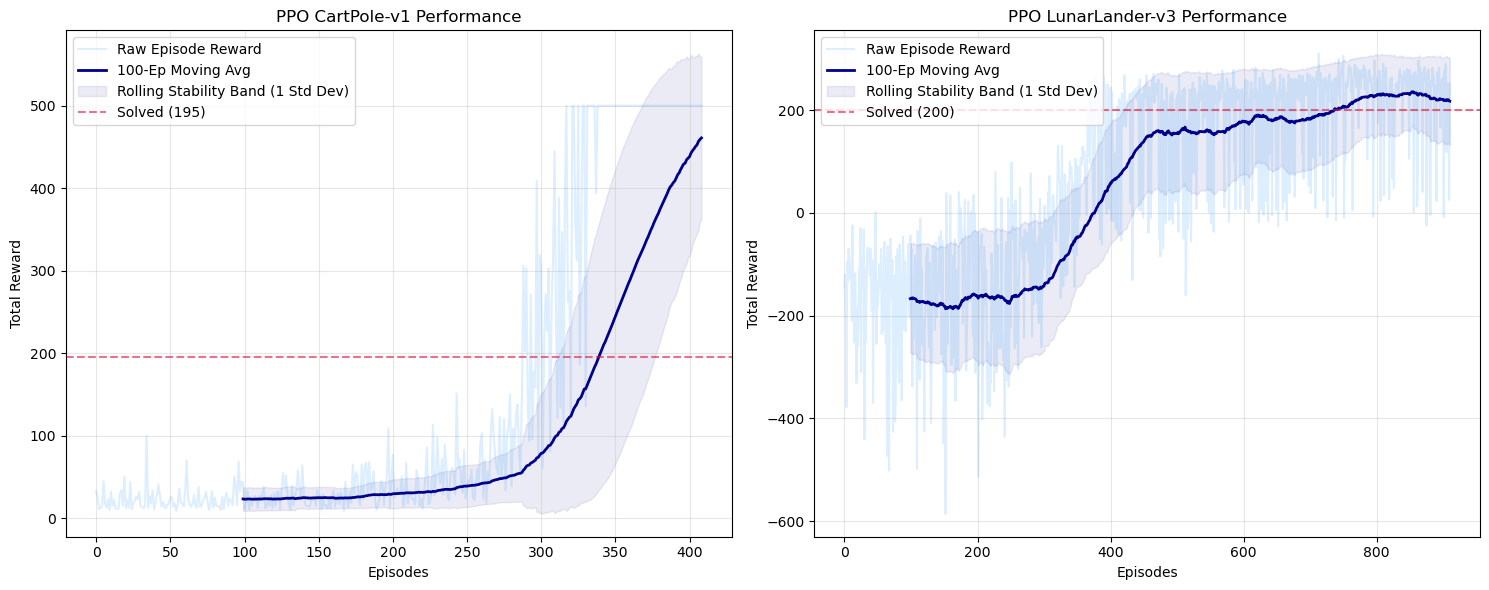

In [18]:
def moving_average(values, window=100):
    if len(values) < window:
        return values
    return np.convolve(values, np.ones(window)/window, mode='valid')

def plot_sb3_run(log_folder, title, solved_threshold):
    results = load_results(log_folder)
    x, y = ts2xy(results, 'episodes')
    
    window = 100
    y_smoothed = moving_average(y, window)
    x_smoothed = x[window - 1:] if len(y) >= window else x

    plt.plot(x, y, alpha=0.15, color='dodgerblue', label='Raw Episode Reward')
    plt.plot(x_smoothed, y_smoothed, color='darkblue', linewidth=2, label=f'{window}-Ep Moving Avg')
    
    if len(y) >= window:
        rolling_std = np.array([np.std(y[max(0, i-window):i+1]) for i in range(len(y))])
        rolling_std_smoothed = rolling_std[window-1:]
        plt.fill_between(x_smoothed, y_smoothed - rolling_std_smoothed, y_smoothed + rolling_std_smoothed, 
                         color='darkblue', alpha=0.08, label='Rolling Stability Band (1 Std Dev)')

    plt.axhline(y=solved_threshold, color='crimson', linestyle='--', alpha=0.6, label=f'Solved ({solved_threshold})')
    plt.title(title)
    plt.xlabel('Episodes')
    plt.ylabel('Total Reward')
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.3)

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plot_sb3_run(cp_log_dir, "PPO CartPole-v1 Performance", solved_threshold=195)

plt.subplot(1, 2, 2)
plot_sb3_run(ll_log_dir, "PPO LunarLander-v3 Performance", solved_threshold=200)

plt.tight_layout()
plt.show()

In [19]:
print("\n" + "="*50)
print("METRICS FOR TASK 3 COMPARISON TABLE:")
print(f"PPO CartPole Train Time: {cartpole_train_time:.1f}s | Final Mean Reward: {mean_reward_cp:.1f}")
print(f"PPO LunarLander Train Time: {ll_train_time:.1f}s | Final Mean Reward: {mean_reward_ll:.1f}")
print("="*50)


METRICS FOR TASK 3 COMPARISON TABLE:
PPO CartPole Train Time: 78.1s | Final Mean Reward: 500.0
PPO LunarLander Train Time: 478.1s | Final Mean Reward: 220.2


### Task 3 — Comparison and Reflection

Fill in this table from your runs in Tasks 1 and 2:

| Agent | Environment | Wall-clock training time | Avg reward (last 100 episodes) |
|---|---|---|---|
| DQN (from scratch) | CartPole-v1 | … | … |
| PPO (SB3) | CartPole-v1 | … | … |
| PPO (SB3) | LunarLander-v2 | … | … |

Then, in a markdown cell, answer the following questions in 3–5 sentences each:

1. Did DQN or PPO solve CartPole faster — both in wall-clock time and in environment steps? Why do you think that is?
2. Could you imagine training the **same DQN code** on `LunarLander-v2` and getting a similar result? What would you expect to go wrong, and which Deep RL improvement from the lesson (Double DQN, Dueling, PER, Rainbow) would you reach for first?
3. Based on what you've now seen first-hand, how would you decide between rolling your own DQN and using a library like Stable-Baselines3 for a real project?

| Agent | Environment | Wall-clock training time | Avg reward (last 100 episodes) |
|---|---|---|---|
| DQN (from scratch) | CartPole-v1 | 83.8s | 161.0 |
| PPO (SB3) | CartPole-v1 | 78.1s | 500.0 |
| PPO (SB3) | LunarLander-v3 | 478.1s | 220.2 |

**1. Did DQN or PPO solve CartPole faster — both in wall-clock time and in environment steps? Why do you think that is?**
PPO won on both fronts. It finished in 78 seconds and easily hit the maximum 500-point cap, whereas the custom DQN took 84 seconds and plateaued around a 161 average. PPO directly optimizes the policy, making it inherently more stable and sample-efficient than DQN's indirect value estimations. Additionally, Stable-Baselines3 runs highly optimized vectorized code under the hood, effortlessly outperforming our basic Python `for` loop that pushes single transitions to a replay buffer.

**2. Could you imagine training the same DQN code on LunarLander-v2 and getting a similar result? What would you expect to go wrong, and which Deep RL improvement from the lesson (Double DQN, Dueling, PER, Rainbow) would you reach for first?**
Dropping this exact DQN code into LunarLander would be a mess. Standard DQN is notorious for overestimating Q-values, which creates massive instability in environments where bad actions have heavy consequences (like crashing a lander). To fix this, I would immediately implement Double DQN. Decoupling the action selection from the action evaluation directly targets that overestimation bias and makes the learning curve far less chaotic.

**3. Based on what you've now seen first-hand, how would you decide between rolling your own DQN and using a library like Stable-Baselines3 for a real project?**
For a real-world engineering project, I am reaching for Stable-Baselines3 every time. Building DQN from scratch is incredibly useful for internalizing the mechanics—like how target network syncs and replay buffers actually interact—but custom implementations are inherently brittle. Libraries like SB3 provide robust, edge-case-tested algorithms, freeing up time to focus on designing the environment and reward functions rather than debugging PyTorch tensor shapes.